# Tutorial: AlphaPose Colab Inference

What this notebook teaches:
- Try the recommended AlphaPose setup path in Colab.
- Detect runtime setup failures and switch to fallback mode.
- Map AlphaPose-style COCO keypoints to canonical schema and export outputs.
- Persist benchmark status without fabricated metrics.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


## Recommended path

AlphaPose setup can break due CUDA and dependency pinning. This notebook checks for an importable runtime first.


In [2]:
import json

alphapose_ready = False
alphapose_error = None

try:
    import alphapose  # type: ignore

    alphapose_ready = True
except Exception as exc:
    alphapose_error = str(exc)

print("alphapose available:", alphapose_ready)
if alphapose_error:
    print("Reason:", alphapose_error)


alphapose available: False
Reason: No module named 'alphapose'


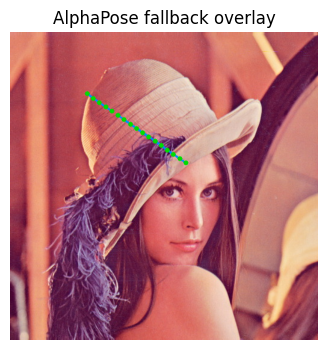

{'tool': 'alphapose',
 'status': 'not_measured',
 'notes': 'Used synthetic COCO-17 fallback sample because AlphaPose is unavailable.'}

In [3]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from posebench.benchmark import write_json
from posebench.export import export_frames_to_csv, export_frames_to_json
from posebench.keypoints_schema import map_tool_keypoints_to_canonical
from posebench.viz import draw_skeleton

sample_path = repo_root / "assets" / "sample_input_walking.jpg"


def download_file(url: str, destination: Path) -> None:
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=20) as response, destination.open("wb") as f:
        f.write(response.read())


def ensure_sample_image(path: Path) -> Path:
    if path.exists():
        return path

    candidates = [
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg",
        "https://images.pexels.com/photos/936075/pexels-photo-936075.jpeg?auto=compress&cs=tinysrgb&w=640",
    ]
    last_error = None
    for url in candidates:
        try:
            download_file(url, path)
            return path
        except Exception as exc:
            last_error = exc

    canvas = np.full((480, 640, 3), 245, dtype=np.uint8)
    cv2.circle(canvas, (320, 100), 36, (40, 40, 40), 3)
    cv2.line(canvas, (320, 136), (320, 320), (40, 40, 40), 3)
    cv2.line(canvas, (320, 200), (250, 260), (40, 40, 40), 3)
    cv2.line(canvas, (320, 200), (390, 260), (40, 40, 40), 3)
    cv2.line(canvas, (320, 320), (270, 430), (40, 40, 40), 3)
    cv2.line(canvas, (320, 320), (370, 430), (40, 40, 40), 3)
    cv2.putText(canvas, "Synthetic fallback image", (170, 460), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (20, 20, 20), 2)
    cv2.imwrite(str(path), canvas)
    print(f"Sample image download failed ({last_error}); synthetic fallback generated.")
    return path

ensure_sample_image(sample_path)

bgr = cv2.imread(str(sample_path))
if bgr is None:
    raise RuntimeError("Could not load sample image")

if alphapose_ready:
    status = {
        "tool": "alphapose",
        "status": "not_measured",
        "notes": "AlphaPose detected. Add project-specific inference command in this cell.",
    }
    points = []
else:
    h, w = bgr.shape[:2]
    points = [
        {"x": (0.25 + 0.02 * i) * w, "y": (0.2 + 0.014 * i) * h, "confidence": 0.7}
        for i in range(17)
    ]
    status = {
        "tool": "alphapose",
        "status": "not_measured",
        "notes": "Used synthetic COCO-17 fallback sample because AlphaPose is unavailable.",
    }

canonical = map_tool_keypoints_to_canonical("alphapose", points, min_confidence=0.1)
frames = [
    {
        "frame_index": 0,
        "timestamp_ms": 0.0,
        "person_id": 0,
        "tool": "alphapose",
        "schema": "coco17",
        "keypoints": canonical,
    }
]

export_frames_to_csv(frames, repo_root / "results" / "alphapose_demo_keypoints.csv")
export_frames_to_json(frames, repo_root / "results" / "alphapose_demo_keypoints.json")
write_json(status, repo_root / "results" / "benchmark_raw_alphapose_demo.json")

render = draw_skeleton(bgr, canonical, min_confidence=0.1)
out_path = repo_root / "assets" / "generated" / "alphapose_fallback_overlay.jpg"
out_path.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(out_path), render)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(render, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("AlphaPose fallback overlay")
plt.show()

status


## Fallback options

- Local GPU environment with pinned AlphaPose dependencies.
- Docker image with known CUDA/PyTorch compatibility.
